# T10 - Particiones en árboles de clasificación

**Alan Yael Almaraz Parra**

En árboles de **regresión** usamos varianza conjunta para decidir las particiones.  
En árboles de **clasificación** las salidas son categorícas, así que necesitamos métricas de *impureza*.



## 0. Importaciones

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import cross_val_score
from sklearn.inspection import DecisionBoundaryDisplay

plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})
COLORS = ['#534AB7', '#1D9E75', '#D85A30']   # púrpura, verde, coral


## 1. Cargamos el dataset Iris

In [2]:
iris = load_iris()
X, y = iris.data, iris.target
feature_names = iris.feature_names
class_names   = iris.target_names


## 2. Implementación manual de criterios

In [3]:
def gini(y):
    n = len(y)
    if n == 0: return 0.0
    probs = np.bincount(y, minlength=3) / n
    return 1 - np.sum(probs**2)

def entropy(y):
    n = len(y)
    if n == 0: return 0.0
    probs = np.bincount(y, minlength=3) / n
    probs = probs[probs > 0]
    return -np.sum(probs * np.log2(probs))

def log_loss_impurity(y):
    n = len(y)
    if n == 0: return 0.0
    probs = np.bincount(y, minlength=3) / n
    probs = probs[probs > 0]
    return -np.sum(probs * np.log(probs))

def ganancia_informacion(y, y_izq, y_der, criterio_fn):
    n = len(y)
    imp_padre = criterio_fn(y)
    imp_hijos = (len(y_izq)/n)*criterio_fn(y_izq) + (len(y_der)/n)*criterio_fn(y_der)
    return imp_padre - imp_hijos

print('Impureza del nodo raíz (antes de cualquier partición):')
print(f'Gini     : {gini(y):.5f}')
print(f'Entropía : {entropy(y):.5f} bits')
print(f'Log Loss : {log_loss_impurity(y):.5f} nats')


Impureza del nodo raíz (antes de cualquier partición):
Gini     : 0.66667
Entropía : 1.58496 bits
Log Loss : 1.09861 nats


## 3. Búsqueda exhaustiva del mejor split

In [4]:
def mejor_split(X, y, criterio_fn):
    mejor_ganancia, mejor_feat, mejor_umbral, mejor_data = -np.inf, None, None, None
    for feat in range(X.shape[1]):
        umbrales = (np.sort(np.unique(X[:, feat]))[:-1] + np.sort(np.unique(X[:, feat]))[1:]) / 2
        for umbral in umbrales:
            mask = X[:, feat] <= umbral
            y_izq, y_der = y[mask], y[~mask]
            if len(y_izq) == 0 or len(y_der) == 0: continue
            g = ganancia_informacion(y, y_izq, y_der, criterio_fn)
            if g > mejor_ganancia:
                mejor_ganancia = g
                mejor_feat     = feat
                mejor_umbral   = umbral
                mejor_data     = (y_izq, y_der, mask)
    return mejor_feat, mejor_umbral, mejor_ganancia, mejor_data


## 4. Primera partición — resultado de cada criterio

In [5]:
criterios = [
    ('GINI',     gini),
    ('ENTROPÍA', entropy),
    ('LOG LOSS', log_loss_impurity),
]

for nombre, fn in criterios:
    feat, umbral, ganancia, data = mejor_split(X, y, fn)
    y_izq, y_der, _ = data
    d_izq = np.bincount(y_izq, minlength=3)
    d_der = np.bincount(y_der, minlength=3)
    puro_izq = 'PURO' if np.max(d_izq)==len(y_izq) else 'impuro'
    puro_der = 'PURO' if np.max(d_der)==len(y_der) else 'impuro'
    print(f'[{nombre}]')
    print(f'  Ganancia : {ganancia:.5f}')
    print(f'  Nodo izq : {len(y_izq):3d} muestras  dist={d_izq}  {puro_izq}')
    print(f'  Nodo der : {len(y_der):3d} muestras  dist={d_der}  {puro_der}')
    print()


[GINI]
  Ganancia : 0.33333
  Nodo izq :  50 muestras  dist=[50  0  0]  PURO
  Nodo der : 100 muestras  dist=[ 0 50 50]  impuro

[ENTROPÍA]
  Ganancia : 0.91830
  Nodo izq :  50 muestras  dist=[50  0  0]  PURO
  Nodo der : 100 muestras  dist=[ 0 50 50]  impuro

[LOG LOSS]
  Ganancia : 0.63651
  Nodo izq :  50 muestras  dist=[50  0  0]  PURO
  Nodo der : 100 muestras  dist=[ 0 50 50]  impuro



## 5. Frontera de decisión
Usamos las dos features más discriminativas: *petal length* y *petal width*.

Lo graficamos a través de gráfica de dispersión de puntos

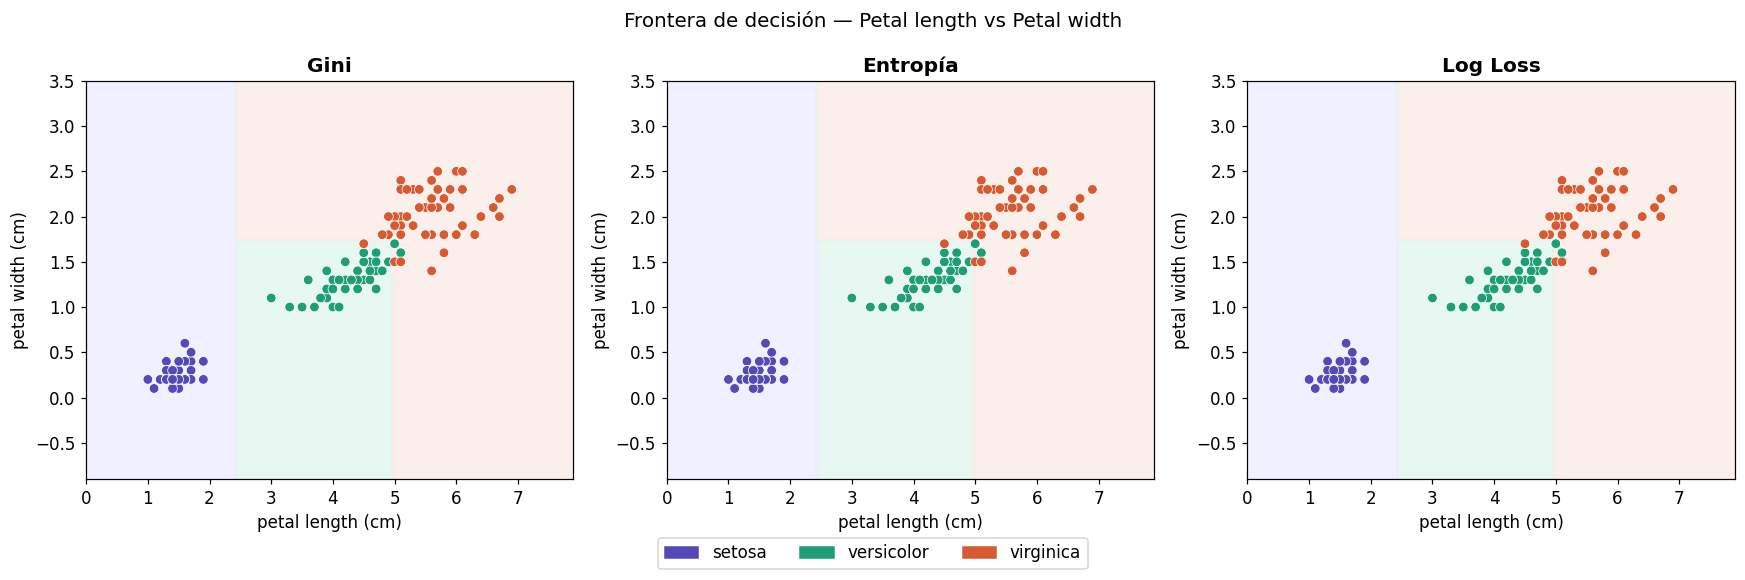

In [6]:
criterios_sk = [('Gini', 'gini'), ('Entropía', 'entropy'), ('Log Loss', 'log_loss')]
X2 = X[:, 2:]   
feat2_names = feature_names[2:]
cmap_bg = ListedColormap(['#EEEDFE', '#E1F5EE', '#FAECE7'])
cmap_pt = ListedColormap(COLORS)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (nombre, crit) in zip(axes, criterios_sk):
    clf2 = DecisionTreeClassifier(criterion=crit, max_depth=3, random_state=42)
    clf2.fit(X2, y)
    DecisionBoundaryDisplay.from_estimator(
        clf2, X2, response_method='predict',
        cmap=cmap_bg, alpha=0.8, ax=ax
    )
    scatter = ax.scatter(X2[:, 0], X2[:, 1], c=y, cmap=cmap_pt, edgecolors='white',
                         linewidths=0.5, s=40, zorder=2)
    ax.set_xlabel(feat2_names[0])
    ax.set_ylabel(feat2_names[1])
    ax.set_title(nombre, fontweight='bold')

handles = [mpatches.Patch(color=COLORS[i], label=class_names[i]) for i in range(3)]
fig.legend(handles=handles, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.05))
plt.suptitle('Frontera de decisión — Petal length vs Petal width', fontsize=13)
plt.tight_layout()
plt.show()


## 6. Comparación de accuracy (Cross-Validation k=5)

In [7]:
print(f'{'Criterio':<12} {'Media':>8} {'Std':>7}')
print('-' * 55)
for nombre, crit in criterios_sk:
    clf = DecisionTreeClassifier(criterion=crit, random_state=42)
    scores = cross_val_score(clf, X, y, cv=5, scoring='accuracy')
    folds_str = '  '.join([f'{s:.3f}' for s in scores])
    print(f'{nombre:<12} {scores.mean():>8.4f} {scores.std():>7.4f}')


Criterio        Media     Std
-------------------------------------------------------
Gini           0.9533  0.0340
Entropía       0.9533  0.0340
Log Loss       0.9533  0.0340


## 7. Conclusiones

- **Gini** Computacionalmente más barato; no requiere logaritmo
- **Entropía** Penaliza más distribuciones uniformes; base 2
- **Log Loss** Igual que entropía en base *e*; orientada a probabilidades


### Diferencia clave: Entropía vs Log Loss
- **Misma curva, distinta escala**
- La diferencia es conceptual: entropía mide *bits de información*; log loss mide *verosimilitud negativa*